## **OPTIMIZATION**
Having established that **XGBoost** provides the best overall performance among the tested models, the next logical step is to optimize its hyperparameters. Fine-tuning will allow us to reduce error, improve generalization, and potentially address the challenge of extrapolating higher RUL values. In the following section, we focus on hyperparameter optimization to further enhance the predictive power of the XGBoost model.

In [6]:
 # Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix , precision_score , recall_score , f1_score , r2_score 
from sklearn.metrics import mean_squared_error

In [2]:
 # Setting up the visualization style 
sns.set_style( style = 'darkgrid' )
sns.set_palette( palette = 'icefire' )

In [3]:
train_dfs = {}
test_dfs = {}

test_csv = ['test FD001 with RUL.csv','test FD002 with RUL.csv','test FD003 with RUL.csv','test FD004 with RUL.csv']
train_csv = ['train FD001 with RUL.csv','train FD002 with RUL.csv','train FD003 with RUL.csv','train FD004 with RUL.csv']

names = ['FD001','FD002','FD003','FD004']

 # loading the datasets
for name , df1 , df2 in zip( names, test_csv, train_csv ):
    test_dfs[name] = pd.read_csv(df1)
    train_dfs[name] = pd.read_csv(df2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 5, 'colsample_bytree': 0.5}
Best CV R²: 0.8330844640731812
******FD001 MODEL PEFORMANCE******
Mean Squared Error (MSE): 315.53
R² Score: 0.82


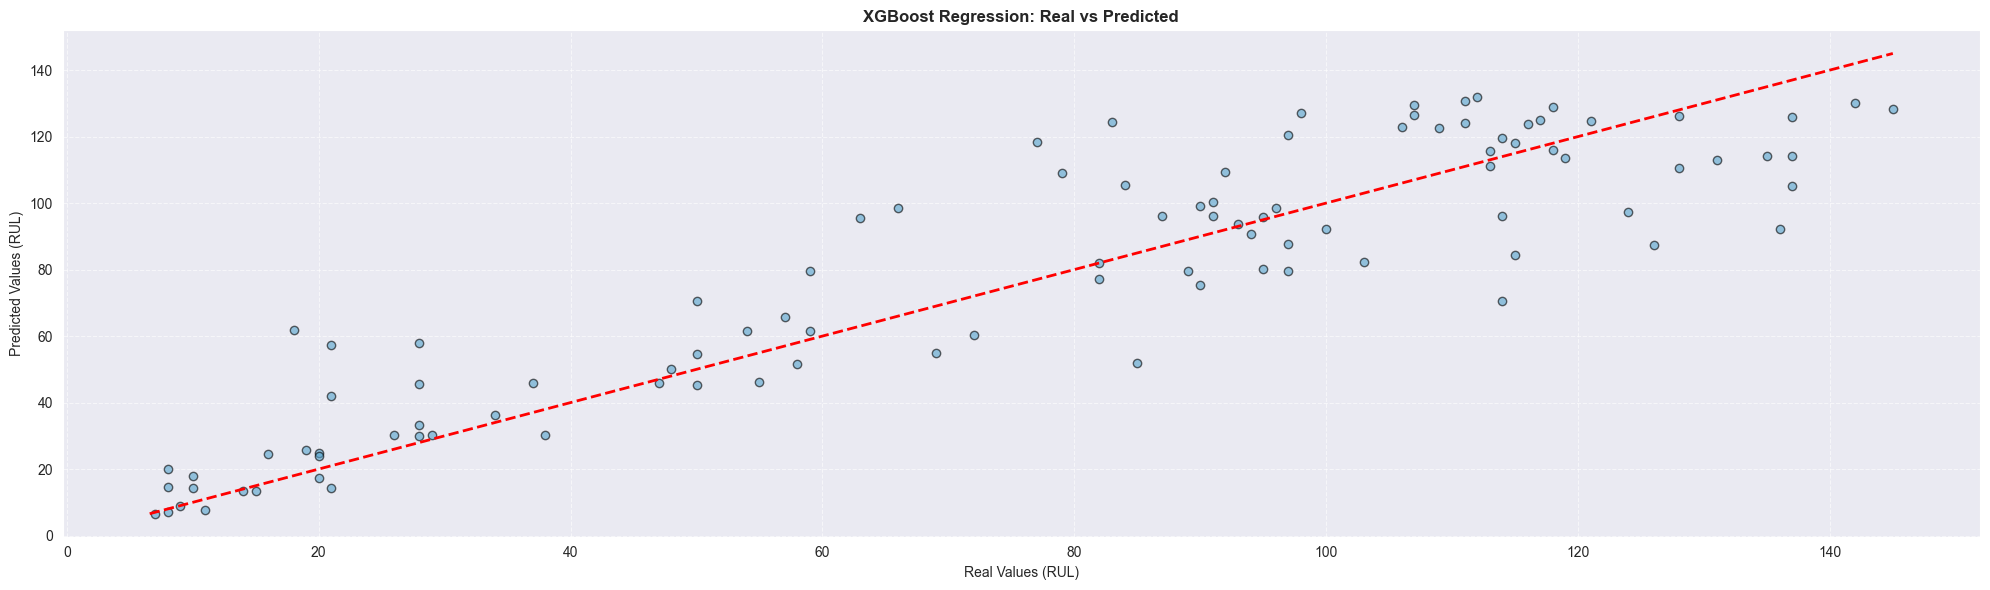

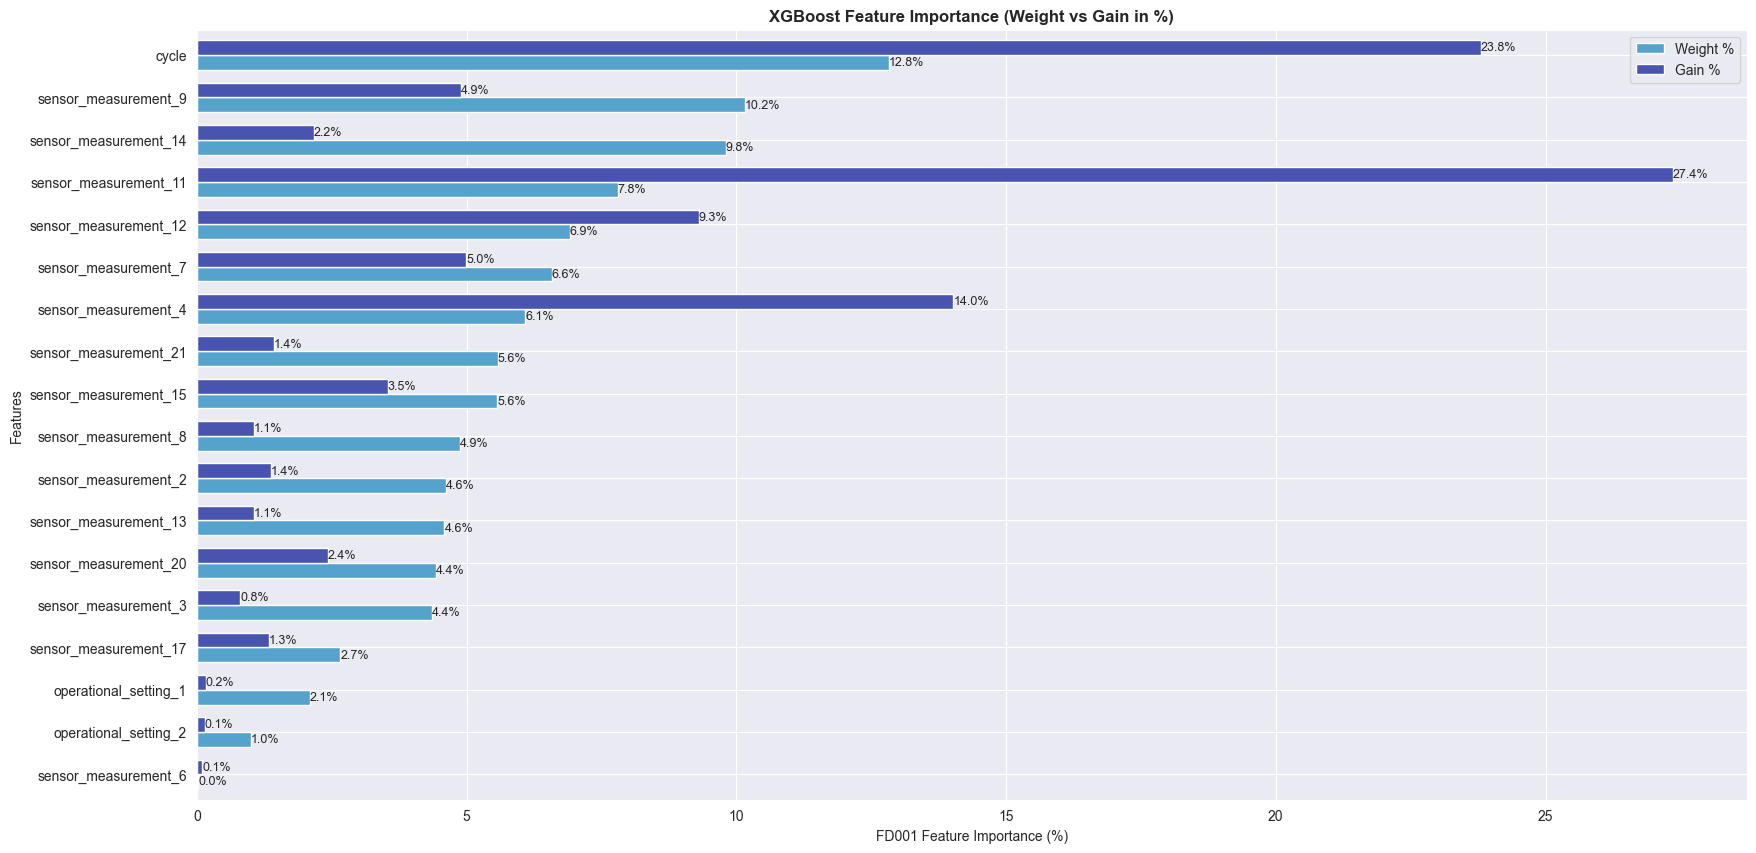

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.5, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 12, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 0.5}
Best CV R²: 0.826881468296051
******FD002 MODEL PEFORMANCE******
Mean Squared Error (MSE): 710.76
R² Score: 0.75


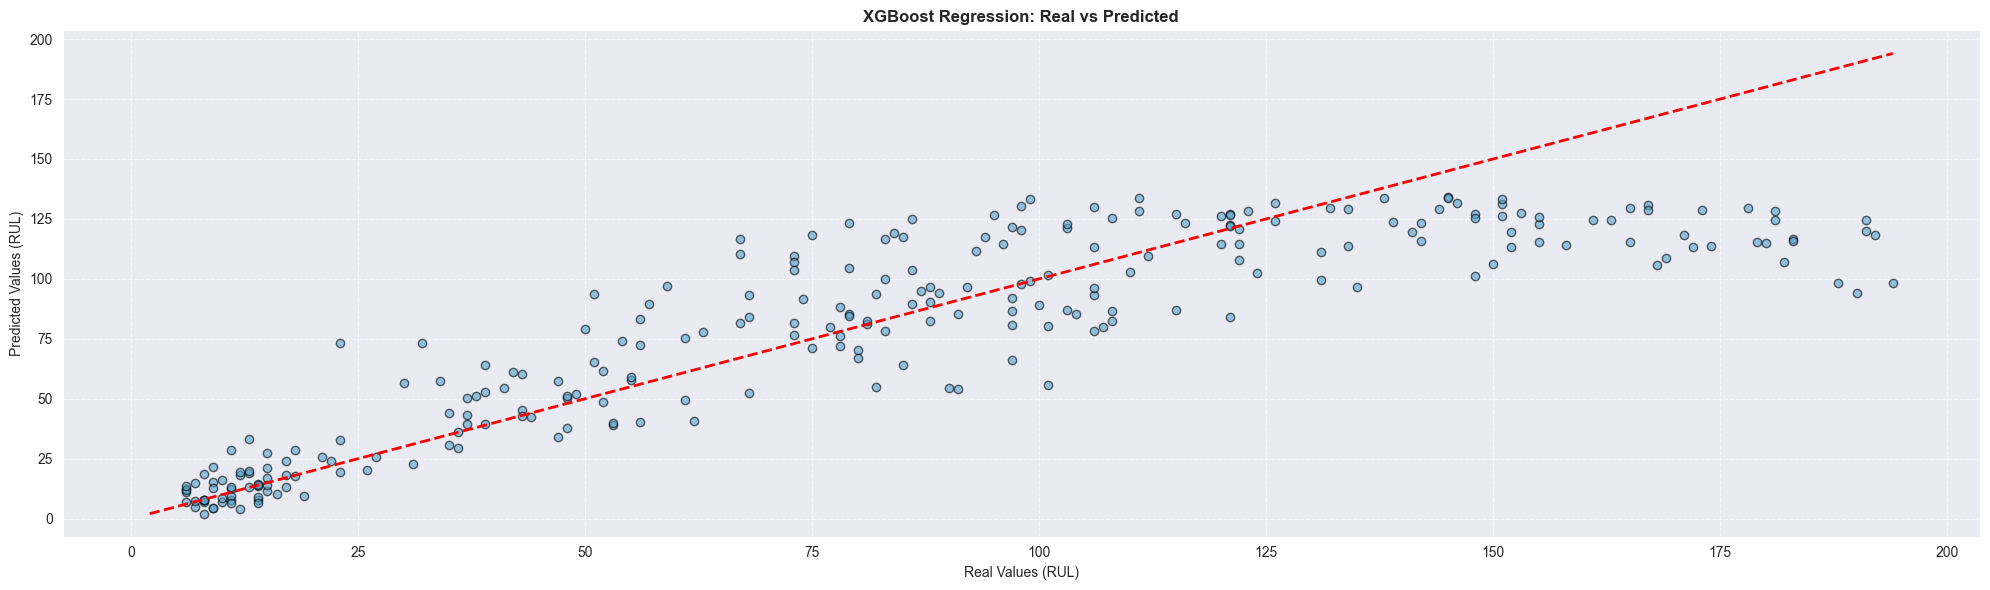

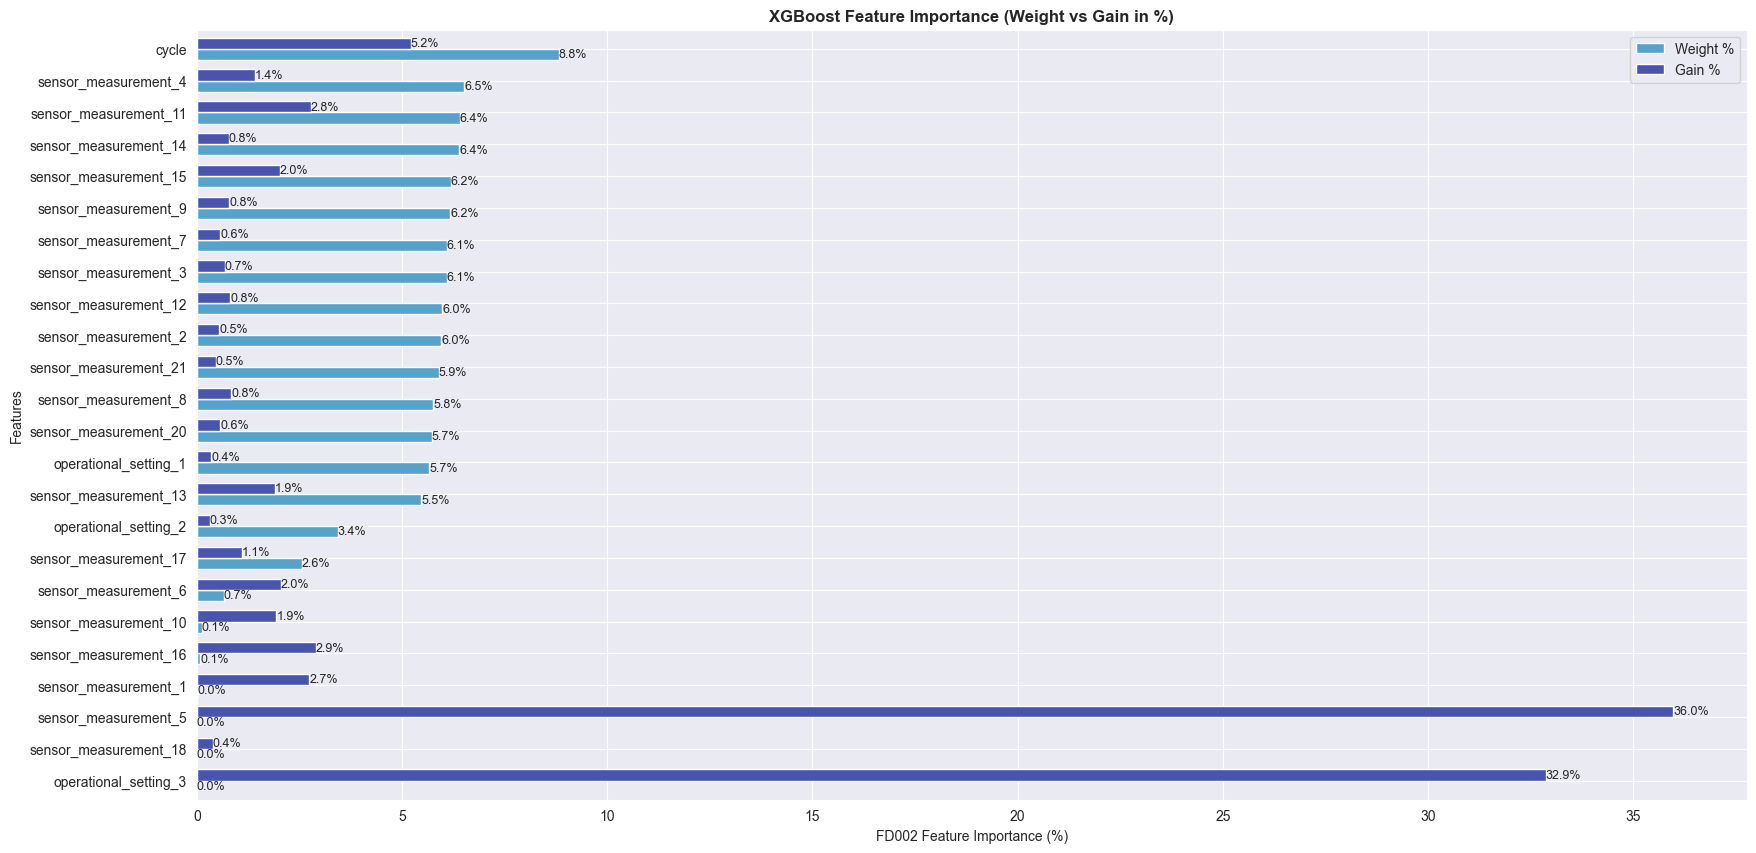

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 5, 'colsample_bytree': 0.5}
Best CV R²: 0.8527099132537842
******FD003 MODEL PEFORMANCE******
Mean Squared Error (MSE): 374.76
R² Score: 0.78


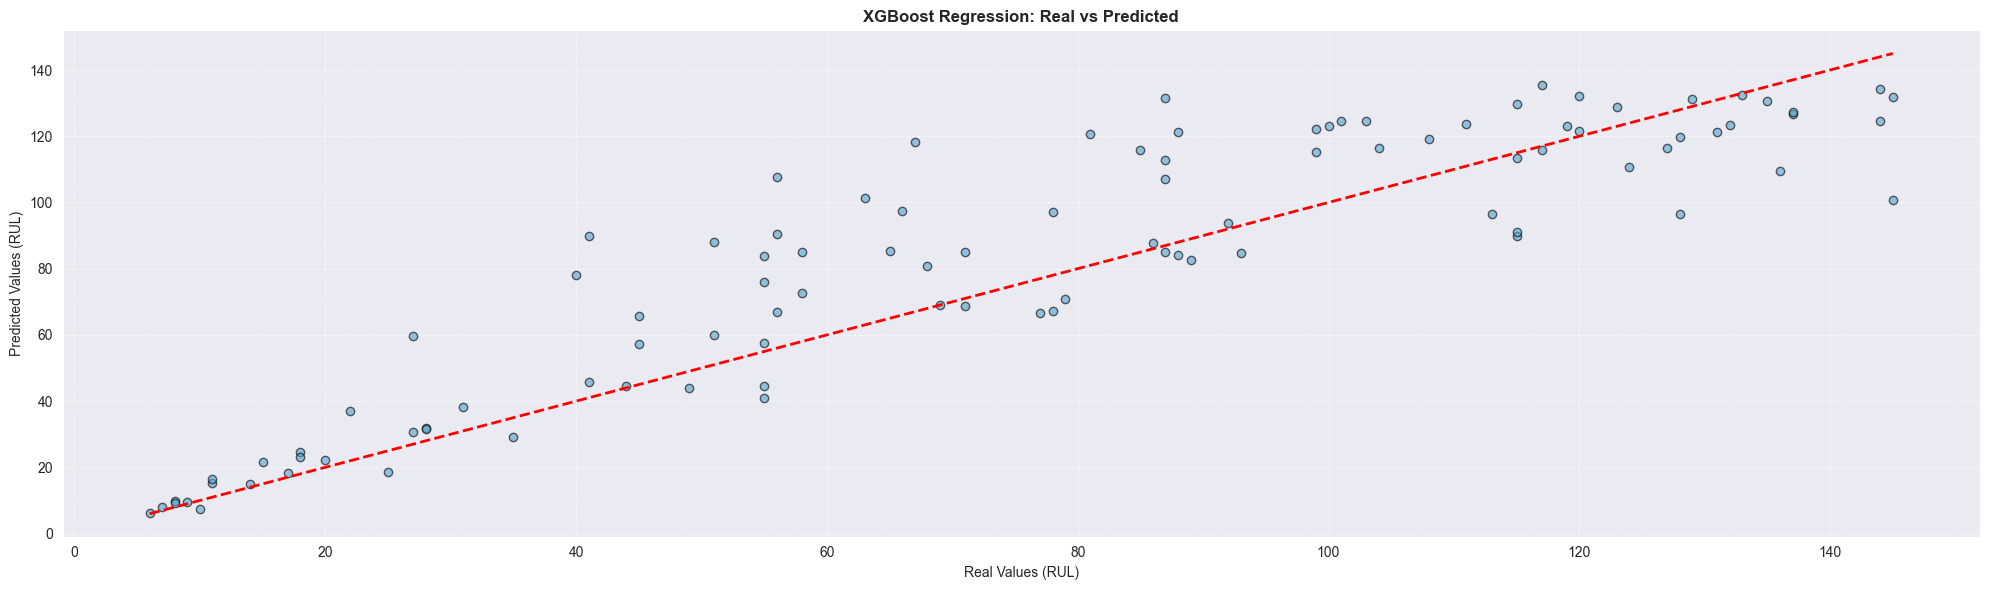

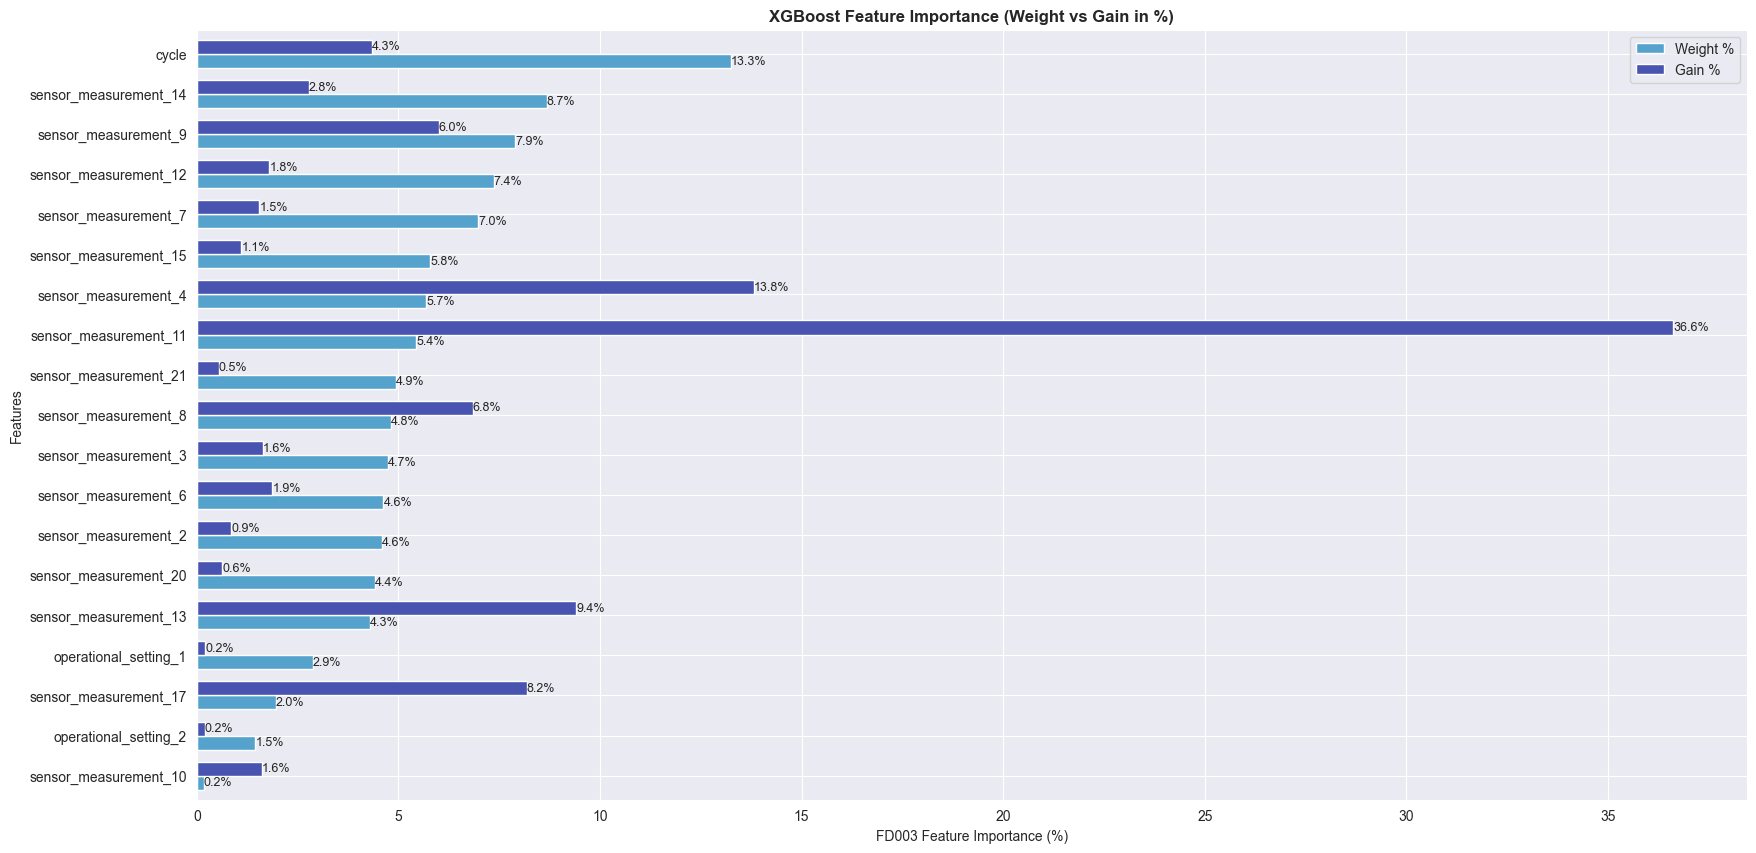

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
 # Modelling using XG boost
r2_list_xgboost = []
mse_list_xgboost = []

for (name1, df1) , (name2, df2)in zip(train_dfs.items(), test_dfs.items()):
    X_train = df1.iloc[ :,1:-1 ]
    y_train = df1.iloc[ :,-1 ]

    X_test = df2.iloc[ :,1:-1 ]
    y_test = df2.iloc[ :,-1 ]
    
    # Define parameter distributions (wider range than GridSearch)
    param_dist = {
        'n_estimators': [100, 300, 500, 800, 1000],
        'max_depth': [3, 5, 7, 9, 12],
        'learning_rate': [0.3, 0.1, 0.05, 0.01, 0.001],
        'subsample': [0.5, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
        'gamma': [0, 1, 5],
        'min_child_weight': [1, 3, 5, 7]
    }

    xgb = XGBRegressor(random_state=42)

    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=50,              
        scoring="r2",           
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Fit
    random_search.fit(X_train, y_train)

    # Best parameters
    print("Best Parameters:", random_search.best_params_)
    print("Best CV R²:", random_search.best_score_)

    best_params = random_search.best_params_

    best_model = XGBRegressor(**best_params, random_state=42)
    best_model.fit(X_train, y_train)

    # Predictions
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    r2_list_xgboost.append(r2)
    mse_list_xgboost.append(mse)


    print(f'******{name1} MODEL PEFORMANCE******')
    print(f'Mean Squared Error (MSE): {mse:.2f}')
    print(f'R² Score: {r2:.2f}')
    
     # Plotting the scatter plot 
    plt.figure(figsize=(20,6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')

    # 45-degree line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    plt.title('XGBoost Regression: Real vs Predicted', fontweight = 'bold')
    plt.xlabel('Real Values (RUL)')
    plt.ylabel('Predicted Values (RUL)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Getting the important features.
    booster = best_model.get_booster()
    weight_dict = booster.get_score(importance_type='weight')
    gain_dict   = booster.get_score(importance_type='gain')

    # Changing to dataframes 
    df_weight = pd.DataFrame.from_dict(weight_dict, orient='index', columns=['weight'])
    df_gain   = pd.DataFrame.from_dict(gain_dict, orient='index', columns=['gain'])

    df_weight['weight'] = 100 * df_weight['weight'] / df_weight['weight'].sum()
    df_gain['gain']     = 100 * df_gain['gain'] / df_gain['gain'].sum()

    # Merge into one DataFrame
    importance_df = df_weight.join(df_gain)
    importance_df = importance_df.sort_values(by='weight', ascending=True)

    # Plot 
    ax = importance_df.plot(
        kind='barh',
        figsize=(20, 10),
        width=0.7
    )

    # Add labels to each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

    plt.xlabel(f'{name1} Feature Importance (%)')
    plt.ylabel('Features')
    plt.title('XGBoost Feature Importance (Weight vs Gain in %)', fontweight = 'bold')
    plt.legend(['Weight %', "Gain %"])
    plt.show()

print('***** MEAN PERFORMANCE *****')
print('R2 MEAN: ', np.mean(r2_list_xgboost))
print('MSE MEAN: ', np.mean(mse_list_xgboost))

for the output after